In [1]:
import altair as alt
import geopandas as gpd
import hvplot.pandas
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from shapely.geometry import Point
from sklearn.cluster import dbscan


np.random.seed(35)
pd.set_option("display.max_columns", None)

%matplotlib inline

In [ ]:
city_limits = gpd.read_file("/Users/prince/philly-tree-mapper/data/raw/City_Limits.geojson")


In [3]:
philly_trees = gpd.read_file("../data/processed/philly_trees.geojson")
philly_trees

,objectid,tree_name,tree_dbh,year,loc_y,loc_x,scientific_name,Genus,Species,geometry
0,1,Ginkgo biloba - ginkgo,36.0,2025,39.983823,-75.210501,Ginkgo biloba,Ginkgo,biloba,POINT (-75.2105 39.98383)
1,2,Acer palmatum - japanese maple,NaN,2025,39.983734,-75.210532,Acer palmatum,Acer,palmatum,POINT (-75.21053 39.98374)
2,3,Acer palmatum - japanese maple,8.0,2025,39.983749,-75.210405,Acer palmatum,Acer,palmatum,POINT (-75.21041 39.98376)
3,4,Acer palmatum - japanese maple,12.0,2025,39.983943,-75.210602,Acer palmatum,Acer,palmatum,POINT (-75.2106 39.98395)
4,5,Acer pseudoplatanus - sycamore maple,17.0,2025,39.983754,-75.210273,Acer pseudoplatanus,Acer,pseudoplatanus,POINT (-75.21028 39.98376)
...,...,...,...,...,...,...,...,...,...,...
150327,151722,Platanus x acerifolia - london planetree,3.0,2025,39.946433,-75.208725,Platanus acerifolia,Platanus,acerifolia,POINT (-75.20873 39.94644)
150328,151723,Platanus x acerifolia - london planetree,2.0,2025,39.946597,-75.208760,Platanus acerifolia,Platanus,acerifolia,POINT (-75.20876 39.9466)
150329,151724,Gleditsia triacanthos - honeylocust,2.0,2025,39.995474,-75.162255,Gleditsia triacanthos,Gleditsia,triacanthos,POINT (-75.16226 39.99548)
150330,151725,Gleditsia triacanthos - honeylocust,2.0,2025,39.995489,-75.162204,Gleditsia triacanthos,Gleditsia,triacanthos,POINT (-75.16221 39.9955)


In [36]:
hoods = gpd.read_file("../data/raw/MUSA_zillow_neighborhoods.geojson")
parks = gpd.read_file("../data/raw/PPR_Properties.geojson")
parks.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [5]:
# Create 2 geodataframes with trees by parks and trees by neighborhood
trees_n_hoods = gpd.sjoin(
    philly_trees,
    hoods,
    predicate="intersects",
    how="left"
)

trees_n_parks = gpd.sjoin(
    philly_trees,
    parks,
    predicate="intersects",
    how="left"
)
trees_out_parks = trees_n_parks.loc[trees_n_parks["index_right"].isna()]

trees_in_parks = trees_n_parks.loc[~trees_n_parks["index_right"].isna()]

pct_trees_in_parks = len(trees_in_parks) / len(philly_trees) * 100

trees_in_hoods = trees_n_hoods.loc[~trees_n_hoods["index_right"].isna()]
trees_out_hoods = trees_n_hoods.loc[trees_n_hoods["index_right"].isna()]
print(len(trees_out_hoods))




356


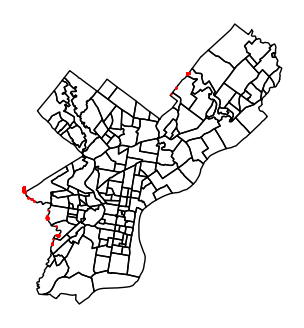

In [6]:
# plot city limits & neighborhoods

fig, ax = plt.subplots(figsize=(4, 4))
hoods.to_crs(epsg=3857).plot(ax=ax, facecolor="none", edgecolor="black")
ax.set_axis_off()
ax.set_aspect("equal")

# Plot the first city in the joined data frame (Vatican City)
# Use the same axes by passing in the ax=ax keyword
ax = trees_out_hoods.to_crs(epsg=3857).plot(ax=ax, color="red", markersize=.5)

353


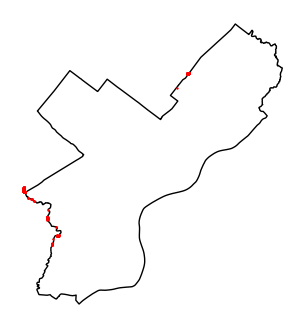

In [7]:
trees_in_city = gpd.sjoin(
    philly_trees,
    city_limits,
    predicate="intersects",
    how="left"
)

trees_out_city = trees_in_city.loc[trees_in_city["index_right"].isna()]
print(len(trees_out_city))

fig, ax = plt.subplots(figsize=(4, 4))
city_limits.to_crs(epsg=3857).plot(ax=ax, facecolor="none", edgecolor="black")
ax.set_axis_off()
ax.set_aspect("equal")

# Plot the first city in the joined data frame (Vatican City)
# Use the same axes by passing in the ax=ax keyword
ax = trees_out_city.to_crs(epsg=3857).plot(ax=ax, color="red", markersize=.5)

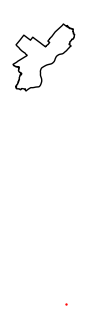

In [8]:
test_point = gpd.GeoDataFrame({
    'column_name': ["fake point"],
    'geometry': [Point(-75, 39)]
}, crs=philly_trees.crs)

fig, ax = plt.subplots(figsize=(4, 4))
city_limits.to_crs(epsg=3857).plot(ax=ax, facecolor="none", edgecolor="black")
ax.set_axis_off()
ax.set_aspect("equal")

# Plot the first city in the joined data frame (Vatican City)
# Use the same axes by passing in the ax=ax keyword
ax = test_point.to_crs(epsg=3857).plot(ax=ax, color="red", markersize=.5)

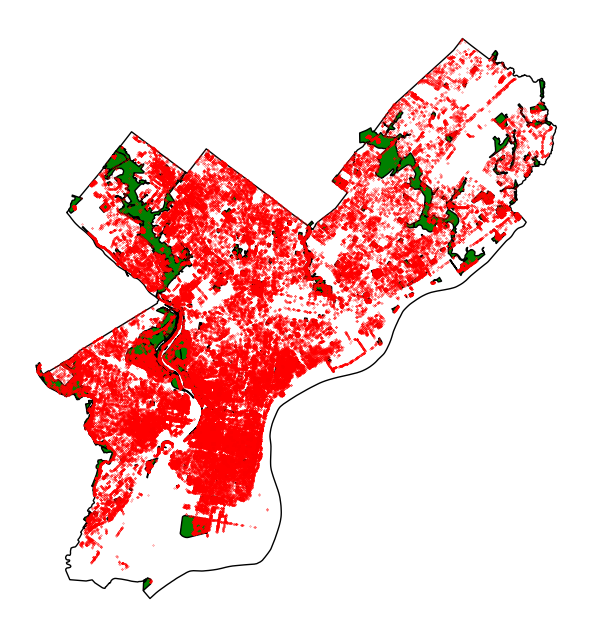

In [9]:
# Plot with city limits, parks, and all trees
fig, ax = plt.subplots(figsize=(8, 8))
city_limits.to_crs(epsg=3857).plot(ax=ax, edgecolor="black", facecolor="white")
ax.set_axis_off()
ax.set_aspect("equal")

# Plot the first city in the joined data frame (Vatican City)
# Use the same axes by passing in the ax=ax keyword
ax = parks.to_crs(epsg=3857).plot(ax=ax, edgecolor="black", facecolor="green")
ax = philly_trees.to_crs(epsg=3857).plot(ax=ax, color="red", markersize=.05)


In [10]:
park_acerifolias = trees_in_parks.loc[trees_in_parks["scientific_name"] == "Platanus acerifolia"]
park_acerifolias


,objectid_left,tree_name,tree_dbh,year,loc_y,loc_x,scientific_name,Genus,Species,geometry,index_right,nested,official_name,label,alias,address_911,zip_code,alias_address,acreage,property_classification,ppr_use,ppr_prog_district,ppr_ops_district,council_district,police_district,program_sites,comments,objectid_right,site_name,park_name,ppr_ranger_district,ppr_park_id,ppr_site_id,ppr_asset_id,Shape__Area,Shape__Length
71,74,Platanus x acerifolia - london planetree,36.0,2025,39.948250,-75.209378,Platanus acerifolia,Platanus,acerifolia,POINT (-75.20938 39.94826),107.0,N,,Clark,,4301 CHESTER AVE,19104,43rd & Woodland;1101 S 45TH ST,12.033968,PARK,NEIGHBORHOOD_PARK,10,8,3,18,N,Rosenberger Hall premises is leased to PAID/Un...,108.0,Clarence H Clark Park,Clarence H Clark Park,S,P0063,P0063-S0000,P0063-S0000-B0000-A0000-X00000,82961.574219,1786.223281
74,77,Platanus x acerifolia - london planetree,36.0,2025,39.948098,-75.209462,Platanus acerifolia,Platanus,acerifolia,POINT (-75.20946 39.94811),107.0,N,,Clark,,4301 CHESTER AVE,19104,43rd & Woodland;1101 S 45TH ST,12.033968,PARK,NEIGHBORHOOD_PARK,10,8,3,18,N,Rosenberger Hall premises is leased to PAID/Un...,108.0,Clarence H Clark Park,Clarence H Clark Park,S,P0063,P0063-S0000,P0063-S0000-B0000-A0000-X00000,82961.574219,1786.223281
77,80,Platanus x acerifolia - london planetree,29.0,2025,39.947895,-75.209342,Platanus acerifolia,Platanus,acerifolia,POINT (-75.20934 39.9479),107.0,N,,Clark,,4301 CHESTER AVE,19104,43rd & Woodland;1101 S 45TH ST,12.033968,PARK,NEIGHBORHOOD_PARK,10,8,3,18,N,Rosenberger Hall premises is leased to PAID/Un...,108.0,Clarence H Clark Park,Clarence H Clark Park,S,P0063,P0063-S0000,P0063-S0000-B0000-A0000-X00000,82961.574219,1786.223281
82,85,Platanus x acerifolia - london planetree,9.0,2025,39.948082,-75.209145,Platanus acerifolia,Platanus,acerifolia,POINT (-75.20915 39.94809),107.0,N,,Clark,,4301 CHESTER AVE,19104,43rd & Woodland;1101 S 45TH ST,12.033968,PARK,NEIGHBORHOOD_PARK,10,8,3,18,N,Rosenberger Hall premises is leased to PAID/Un...,108.0,Clarence H Clark Park,Clarence H Clark Park,S,P0063,P0063-S0000,P0063-S0000-B0000-A0000-X00000,82961.574219,1786.223281
83,86,Platanus x acerifolia - london planetree,10.0,2025,39.948040,-75.209136,Platanus acerifolia,Platanus,acerifolia,POINT (-75.20914 39.94805),107.0,N,,Clark,,4301 CHESTER AVE,19104,43rd & Woodland;1101 S 45TH ST,12.033968,PARK,NEIGHBORHOOD_PARK,10,8,3,18,N,Rosenberger Hall premises is leased to PAID/Un...,108.0,Clarence H Clark Park,Clarence H Clark Park,S,P0063,P0063-S0000,P0063-S0000-B0000-A0000-X00000,82961.574219,1786.223281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146837,148029,Platanus x acerifolia - london planetree,2.0,2025,39.933658,-75.228807,Platanus acerifolia,Platanus,acerifolia,POINT (-75.22881 39.93367),136.0,N,Francis J. Myers Recreation Center,FJ Myers,,5800 CHESTER AVE,19143,58th & Kingsessing;5801 KINGSESSING AVE,7.625046,PARK,RECREATION_SITE,10,8,2,12,Y,Rebuild Renovations stated in 2024,137.0,Francis J Myers Recreation Center,Francis J Myers Recreation Center,S,P0097,P0097-S0000,P0097-S0000-B0000-A0000-X00000,52546.113281,935.559657
147225,148429,Platanus x acerifolia - london planetree,2.0,2025,39.981935,-75.134853,Platanus acerifolia,Platanus,acerifolia,POINT (-75.13485 39.98194),151.0,N,Norris Square,Norris,,2100 N HOWARD ST,19122,"2100-60 N HOWARD ST, Diamond & Hancock",6.400641,PARK,SQUARE_PLAZA,8,6,7,26,N,Site Renovations started in 2022,152.0,Norris Square,Norris Square,S,P0111,P0111-S0000,P0111-S0000-B0000-A0000-X00000,44170.730469,823.895800
147692,148899,Platanus x acerifolia - london planetree,4.0,2025,39.978240,-75.177983,Platanus acerifolia,Platanus,acerifolia,POINT (-75.17798 39.97825),192.0,N,Athletic Recreation Center,Athletic,Jefferson Baseball Grounds;26th and Master;Ath...,2626 W JEFFERSON ST,19121,"1450 N 26TH ST; 1420 N 26TH ST, 1401-55 N 27TH ST",4.693424,PA

In [11]:
parks_with_most_trees = trees_in_parks.groupby("site_name", as_index=False).size().sort_values(by="size", ascending=False)
parks_with_most_trees

,site_name,size
455,West Fairmount Park,4552
124,East Fairmount Park,2918
91,Cobbs Creek Park,1632
173,Franklin Delano Roosevelt Park,1236
421,Tacony Creek Park,956
...,...,...
393,Sedgely and Fletcher Warehouse,1
326,Northeast Older Adult Center,1
481,Yorktown at Betsy Ross Pl,1
330,Officer Robert Hayes Memorial Playground Woods,1


In [12]:
park_species_groups = trees_in_parks.groupby(["site_name", "scientific_name"]).size().unstack(fill_value=0)
park_species_groups




scientific_name,,Abies balsamea,Abies fraseri,Abies species,Acer buergeranum,Acer campestre,Acer freemanii,Acer ginnala,Acer griseum,Acer negundo,Acer nigrum,Acer palmatum,Acer pensyvanicum,Acer platanoides,Acer pseudoplatanus,Acer rubrum,Acer saccharinum,Acer saccharum,Acer species,Acer tataricum,Acer triflorum,Acer truncatum,Aesculus carnea,Aesculus glabra,Aesculus hippocastanum,Aesculus octandra,Aesculus species,Ailanthus altissima,Albizia julibrissin,Alnus glutinosa,Alnus species,Amelanchier grandiflora,Amelanchier laevis,Amelanchier species,Asimina triloba,Betula alleghaniensis,Betula lenta,Betula nigra,Betula papyrifera,Betula populifolia,Betula species,Broussonetia papyrifera,Carpinus betulus,Carpinus caroliniana,Carya cordiformis,Carya glabra,Carya illinoensis,Carya laciniosa,Carya ovata,Carya species,Carya tomentosa,Castanea dentata,Castanea mollissima,Castanea pumila,Castanea species,Casuarina equisetifolia,Catalpa bignonioides,Catalpa speciosa,Cedrella sinensis,Cedrus atlantica,Cedrus deodara,Celtis laevigata,Celtis occidentalis,Cercidiphyllum japonicum,Cercis canadensis,Chamaecyparis thyoides,Chionanthus retusus,Chionanthus virginicus,Cladrastis kentukea,Cornus florida,Cornus kousa,Cornus mas,Cornus species,Corylus colurna,Cotinus coggygria,Crataegus crus,Crataegus marshallii,Crataegus monogyna,Crataegus phaenopyrum,Crataegus species,Crataegus viridis,Cryptomeria japonica,Cupressus species,Diospyros virginiana,Elaeagnus umbellata,Eucommia ulmoides,Euonymus atropurpureus,Fagus grandifolia,Fagus species,Fagus sylvatica,Ficus carica,Franklinia alatamaha,Fraxinus americana,Fraxinus nigra,Fraxinus pennsylvanica,Fraxinus species,Ginkgo biloba,Gleditsia triacanthos,Gleditsia triacanthos inermis,Gymnocladus dioicus,Halesia carolina,Hamamelis virginiana,Hibiscus syriacus,Ilex opaca,Ilex species,Juglans cinerea,Juglans nigra,Juglans regia,Juniperus virginiana,Kalopanax semtemlobus,Koelreuteria paniculata,Lagerstroemia indica,Larix decidua,Larix laricina,Liquidambar styraciflua,Liriodendron tulipifera,Maackia amurensis,Maclura pomifera,Magnolia acuminata,Magnolia grandiflora,Magnolia soulangiana,Magnolia species,Magnolia stellata,Magnolia tripetala,Magnolia virginiana,Malus pumila,Malus species,Metasequoia glyptostroboides,Morus alba,Morus rubra,Nyssa sylvatica,Ostrya virginiana,Oxydendrum arboreum,Parrotia persica,Paulownia tomentosa,Phellodendron amurense,Picea glauca,Picea mariana,Picea pungens,Picea species,Pinus nigra,Pinus resinosa,Pinus rigida,Pinus species,Pinus strobus,Pinus sylvestris,Pinus taeda,Pinus virginiana,Platanus acerifolia,Platanus occidentalis,Poplar species,Populus alba,Populus deltoides,Populus grandidentata,Populus tremuloides,Populus trichocarpa,Prunus yedoensis,Prunus americana,Prunus armeniaca,Prunus avium,Prunus caroliniana,Prunus cerasifera,Prunus incamp,Prunus maackii,Prunus padus,Prunus pennsylvanica,Prunus persica,Prunus sargentii,Prunus serotina,Prunus serrulata,Prunus species,Prunus subhirtella,Prunus triloba,Prunus virginiana,Pseudotsuga menziesii,Pyrus calleryana,Pyrus communis,Quercus acutissima,Quercus alba,Quercus bicolor,Quercus coccinea,Quercus ellipsoidalis,Quercus falcata,Quercus imbricaria,Quercus laevis,Quercus lyrata,Quercus macrocarpa,Quercus marilandica,Quercus michauxii,Quercus muehlenbergii,Quercus palustris,Quercus phellos,Quercus prinus,Quercus robur,Quercus rubra,Quercus shumardii,Quercus species,Quercus stellata,Quercus velutina,Quercus warei,Rhus glabra,Rhus typhina,Robinia pseudoacacia,Salix babylonica,Salix matsudana,Salix nigra,Salix species,Sassafras albidum,Shrub shrub,Sophora japonica,Sorbus species,Stewartia koreana,Stewartia species,Styrax japonicus,Syringa reticulata,Syringia reticulata,Taxodium distichum,Taxus species,Tetradium daniellii,Thuja occidentalis,Thuja orientalis,Tilia americana,Tilia cordata,Tilia species,Tilia tomentosa,Tsuga canadensis,Ulmus americana,Ulmus parvifolia,Ulmus procera,Ulmus pumila,Ulmus rubra,Ulmus species,Ulmus thomasii,Viburnum trilo

In [26]:
# Create subset of trees data w just platanus acerifolia
platanus_acerifolias = philly_trees.loc[philly_trees["scientific_name"] == "Platanus acerifolia"].reset_index()
platanus_acerifolias_3857 = platanus_acerifolias.to_crs(crs=3857)

# create x y labels from 3857 data
platanus_acerifolias_3857["x"] = platanus_acerifolias_3857.geometry.x
platanus_acerifolias_3857["y"] = platanus_acerifolias_3857.geometry.y


# Do the same for entire philly trees
philly_trees_3857 = philly_trees.to_crs(crs=3857)
philly_trees_3857["x"] = philly_trees_3857.geometry.x
philly_trees_3857["y"] = philly_trees_3857.geometry.y

In [32]:
# Trying out dbscan clustering
eps = 50
min_samples = 25
cores, labels = dbscan(platanus_acerifolias_3857[["x", "y"]], eps=eps, min_samples=min_samples)


In [33]:
print(len(cores))

41
